# Readme

### Context and Significance:
1. As more and more companies are digitalising many aspects of their business, data controls have risen in importance, and many companies would require ISO 270001 certified vendors to deal with them.
2. To mimic the ISO 27001 ceritification where it would be expensive and unnecessary to buy for a personal project. NIST SP 800 (Revision 5) would be replaced as for data to investigate GraphRAG capabilities
3. Company data is also too confidential and private to obtain, hence the GitLab handbook, where it's totally free to distribute and totally open to mimic a proxy company environment to test against the RAG capabilities and insights.

# To Do List:
1. Download the Pages detailing the Access Control Dataset from the NIST SP 800
    a. First Figure out the API data and determined if it's needed to use the API data or just use the CSV data to ingest✅(use text data instead)
2. Download the data from the GitLab Handbook (TBC the session to disgest into the RAG)✅
3. First, check for various retrieval evaluation metrics before moving on to the next stage, making a checkpoint.
    a. Use LLM to prepare a synthetic eval dataset that could be vetted
    b. Explore the usage of RAGAS and DeepEval in industry to help evaluate RAG

In [56]:
import dill
import os
import IPython

# The path to save the state in the workspace folder
state_file = os.path.join(os.getcwd(), 'notebook_vars.pkl')

def save_notebook_session(*args, **kwargs):
    ipython = IPython.get_ipython()
    to_save = {}
    for k, v in ipython.user_ns.items():
        if k.startswith('_') or k in ['In', 'Out', 'get_ipython', 'exit', 'quit']:
            continue
        if type(v).__name__ in ['module', 'function', 'builtin_function_or_method', 'type']:
            continue
        try:
            # strictly serialize to bytes first to avoid compound dict serialization errors
            serialized = dill.dumps(v)
            to_save[k] = serialized
        except Exception:
            pass
            
    try:
        with open(state_file, 'wb') as f:
            dill.dump(to_save, f)
    except Exception as e:
        print(f"Failed to save notebook state: {e}")

ipython = IPython.get_ipython()
if ipython is not None:
    if os.path.exists(state_file):
        try:
            with open(state_file, 'rb') as f:
                saved_vars_serialized = dill.load(f)
            
            loaded_count = 0
            for k, serialized in saved_vars_serialized.items():
                try:
                    v = dill.loads(serialized)
                    ipython.user_ns[k] = v
                    loaded_count += 1
                except Exception:
                    pass
            print(f"Successfully loaded {loaded_count} variables from {state_file}")
        except Exception as e:
            print(f"Failed to load notebook state: {e}")
            
    if save_notebook_session not in ipython.events.callbacks['post_run_cell']:
        ipython.events.register('post_run_cell', save_notebook_session)


Successfully loaded 0 variables from /Users/june/Desktop/Project/AC-Proxy-Audit/notebook/notebook_vars.pkl
Failed to save notebook state: cannot pickle 'SSLContext' object


In [ ]:
# %pip install -q langchain openai chromadb


In [53]:
import numpy as np
import requests
import json
import dill
import time
import os
import re



# EDA
import matplotlib.pyplot as plt

# RAG Pipeline
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
# from langchain_community.vectorstores import Chroma
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

# DeepEval
import os
from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric
)
from deepeval.test_case import LLMTestCase
from deepeval import evaluate


# Data Collection

In [2]:
# NIST SP 800-53 text
def fetch_nist_txt():
    """
    Fetches the official NIST SP 800-53 Rev 5 catalog in txt format and return it list, whereby each element contains one policy / subpolicy (AC-01 / AC-02(04))
    Source: https://csrc.nist.gov/projects/risk-management/sp800-53-controls/downloads.
    """
    print("📥 Downloading NIST SP 800-53 Rev 5 txt file...")
    # Downloading from the text object is easier to process
    url = "https://csrc.nist.gov/files/pubs/sp/800/53/a/r5/final/docs/sp800-53ar5-assessment-procedures.txt"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        print("✅ Download Complete.")
        return [i for i in response.text.split("\n\n")]
    except Exception as e:
        print(f"❌ Failed to download: {e}")
        return None

nist = fetch_nist_txt()

print(nist[:5])


📥 Downloading NIST SP 800-53 Rev 5 txt file...
✅ Download Complete.
['\n4.1 Access Control\nAC-01 POLICY AND PROCEDURES\nASSESSMENT OBJECTIVE:\nDetermine if: \nAC-01_ODP[01] personnel or roles to whom the access control policy is to be disseminated is/are defined;\nAC-01_ODP[02] personnel or roles to whom the access control procedures are to be disseminated is/are defined;\nAC-01_ODP[03] one or more of the following PARAMETER VALUES is/are selected: {organization-level; mission/business process-level; system-level};\nAC-01_ODP[04] an official to manage the access control policy and procedures is defined;\nAC-01_ODP[05] the frequency at which the current access control policy is reviewed and updated is defined;\nAC-01_ODP[06] events that would require the current access control policy to be reviewed and updated are defined;\nAC-01_ODP[07] the frequency at which the current access control procedures are reviewed and updated is defined;\nAC-01_ODP[08] events that would require procedures 

In [3]:
# Isolate the Access Control (AC) section into a new variable
nist_ac_text = [policy.strip() for policy in nist if policy.strip().startswith(('AC-', '4.1 Access Control'))]

# View the result to ensure it captured the Access Control data
print(f"Isolated {len(nist_ac_text)} Access Control policies.")

# Preview to the text
# nist_ac_text[-1]

Isolated 147 Access Control policies.


In [4]:
# Gitlab Company Handbook
# !git clone https://gitlab.com/gitlab-com/content-sites/handbook.git

In [5]:
def clean_for_rag(text):
    # 1. Strip Hugo YAML frontmatter (everything between the first --- and ---)
    text = re.sub(r'^---[\s\S]*?---\n', '', text)
    
    # 2. Extract text from markdown links: [My Link](https://...) -> My Link
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    
    # 3. Remove basic HTML tags occasionally used in the handbook
    text = re.sub(r'<[^>]+>', '', text)
    
    return text.strip()

handbook_dir = '../handbook/content/handbook'
rag_corpus = {}

# Walk through the directory to segregate by section
for root, _, files in os.walk(handbook_dir):
    for file in files:
        if file.endswith('.md'):
            file_path = os.path.join(root, file)
            # Use the relative file path as the section identifier
            section_name = os.path.relpath(file_path, handbook_dir)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                raw_content = f.read()
                
            clean_text = clean_for_rag(raw_content)
            
            # Store non-empty documents in your corpus dictionary
            if clean_text:
                rag_corpus[section_name] = clean_text

print(f"Successfully processed {len(rag_corpus)} handbook sections for RAG.")

# Example: Print the cleaned content of a specific section
# print(rag_corpus["_index.md"])

Successfully processed 3931 handbook sections for RAG.


# EDA 

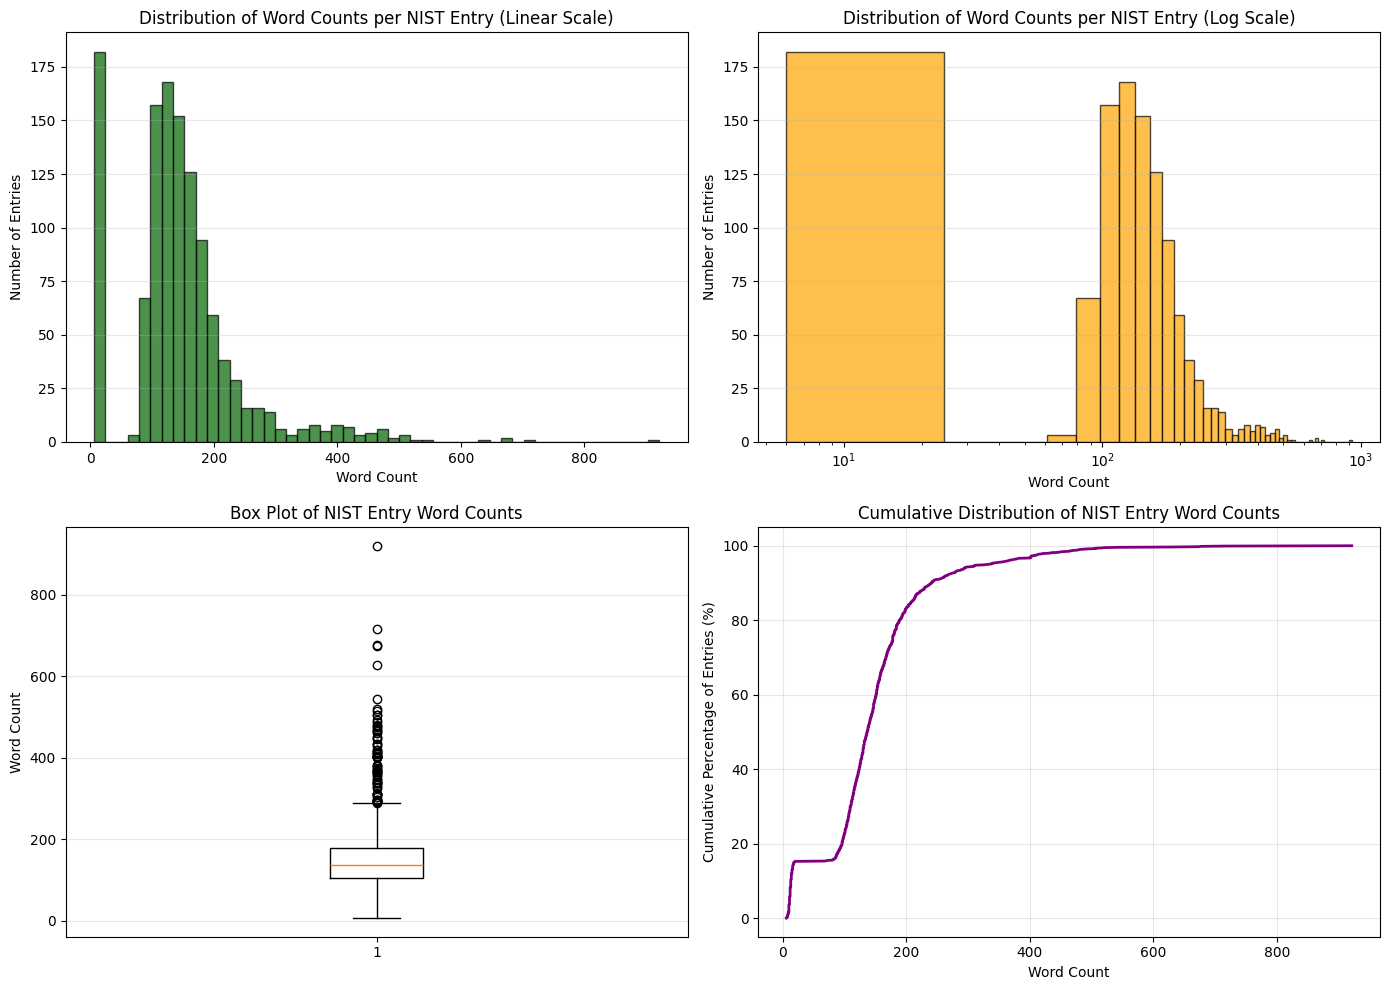


NIST Entry Word Count Statistics:
Total entries: 1189
Total words: 173,491
Mean: 145.9 words
Median: 137.0 words
Std Dev: 97.5 words
Min: 6 words
Q1 (25th percentile): 104.0 words
Q3 (75th percentile): 178.0 words
Max: 921 words


In [6]:
# Analyze word count distribution for NIST control entries
nist_word_counts = [len(entry.split()) for entry in nist if entry.strip()]

# Create figure with subplots for NIST distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of word counts (linear scale)
axes[0, 0].hist(nist_word_counts, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Entries')
axes[0, 0].set_title('Distribution of Word Counts per NIST Entry (Linear Scale)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of word counts (log scale for better visibility)
axes[0, 1].hist(nist_word_counts, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Entries')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribution of Word Counts per NIST Entry (Log Scale)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot to show quartiles and outliers
axes[1, 0].boxplot(nist_word_counts, vert=True)
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Box Plot of NIST Entry Word Counts')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cumulative distribution
sorted_nist_wc = np.sort(nist_word_counts)
cumulative_nist = np.arange(1, len(sorted_nist_wc) + 1) / len(sorted_nist_wc) * 100
axes[1, 1].plot(sorted_nist_wc, cumulative_nist, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Cumulative Percentage of Entries (%)')
axes[1, 1].set_title('Cumulative Distribution of NIST Entry Word Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for NIST
nist_wc_array = np.array(nist_word_counts)
print(f"\nNIST Entry Word Count Statistics:")
print(f"Total entries: {len(nist_word_counts)}")
print(f"Total words: {nist_wc_array.sum():,}")
print(f"Mean: {nist_wc_array.mean():.1f} words")
print(f"Median: {np.median(nist_wc_array):.1f} words")
print(f"Std Dev: {nist_wc_array.std():.1f} words")
print(f"Min: {nist_wc_array.min()} words")
print(f"Q1 (25th percentile): {np.percentile(nist_wc_array, 25):.1f} words")
print(f"Q3 (75th percentile): {np.percentile(nist_wc_array, 75):.1f} words")
print(f"Max: {nist_wc_array.max():,} words")

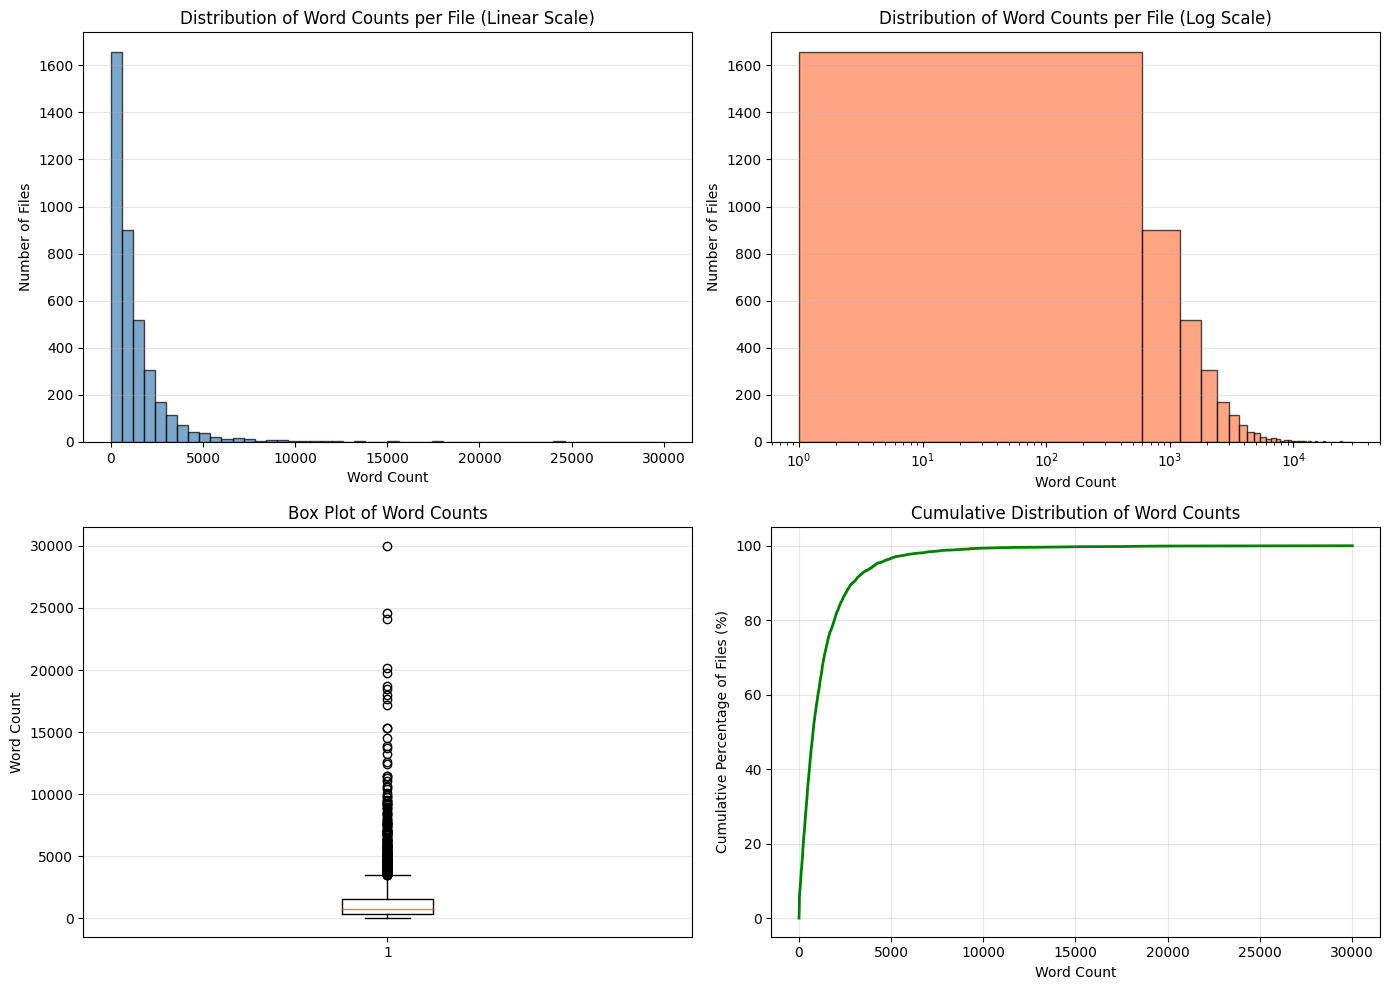


Word Count Statistics:
Total files: 3931
Total words: 5,114,695
Mean: 1301.1 words
Median: 763.0 words
Std Dev: 1855.8 words
Min: 1 words
Q1 (25th percentile): 314.0 words
Q3 (75th percentile): 1580.0 words
Max: 30,018 words


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Compute word counts for each file
word_counts = {name: len(text.split()) for name, text in rag_corpus.items()}
wc_values = list(word_counts.values())

# Create figure with subplots for better visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of word counts (linear scale)
axes[0, 0].hist(wc_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Files')
axes[0, 0].set_title('Distribution of Word Counts per File (Linear Scale)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of word counts (log scale for better visibility of distribution)
axes[0, 1].hist(wc_values, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Files')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribution of Word Counts per File (Log Scale)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot to show quartiles and outliers
axes[1, 0].boxplot(wc_values, vert=True)
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Box Plot of Word Counts')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cumulative distribution
sorted_wc = np.sort(wc_values)
cumulative = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc) * 100
axes[1, 1].plot(sorted_wc, cumulative, linewidth=2, color='green')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Cumulative Percentage of Files (%)')
axes[1, 1].set_title('Cumulative Distribution of Word Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
wc_array = np.array(wc_values)
print(f"\nWord Count Statistics:")
print(f"Total files: {len(wc_values)}")
print(f"Total words: {wc_array.sum():,}")
print(f"Mean: {wc_array.mean():.1f} words")
print(f"Median: {np.median(wc_array):.1f} words")
print(f"Std Dev: {wc_array.std():.1f} words")
print(f"Min: {wc_array.min()} words")
print(f"Q1 (25th percentile): {np.percentile(wc_array, 25):.1f} words")
print(f"Q3 (75th percentile): {np.percentile(wc_array, 75):.1f} words")
print(f"Max: {wc_array.max():,} words")

# Data Pre-processing

# Archive

In [8]:
# # Get the context right when extracting the context from the vector DB (Start small mainly focusing on the Access Control part ofthe NIST SP 800 Rev8)

# def fetch_nist_oscal():
#     """
#     Fetches the official NIST SP 800-53 Rev 5 catalog in OSCAL JSON format.
#     Source: NIST Open Security Controls Assessment Language (OSCAL) GitHub Repository.
#     """
#     print("📥 Downloading NIST SP 800-53 Rev 5 OSCAL JSON...")
#     # url = "https://raw.githubusercontent.com/usnistgov/oscal-content/main/nist.gov/SP800-53/rev5/json/NIST_SP-800-53_rev5_catalog.json"
#     # Downloading from the text object is easier to process
#     url = "https://csrc.nist.gov/files/pubs/sp/800/53/a/r5/final/docs/sp800-53ar5-assessment-procedures.txt"
    
#     try:
#         response = requests.get(url)
#         response.raise_for_status()
#         print("✅ Download Complete.")
#         return response.json()
#     except Exception as e:
#         print(f"❌ Failed to download: {e}")
#         return None

# def extract_control_text(parts):
#     """
#     Recursively extracts text from the deep nesting of OSCAL 'parts'.
#     NIST hides the actual rule text inside nested lists of 'parts'.
#     """
#     text_content = []
    
#     if not parts:
#         return ""
        
#     for part in parts:
#         # 'prose' is where the actual human-readable rule lives
#         if 'prose' in part:
#             text_content.append(part['prose'])
        
#         # Recursively check for sub-parts (like AC-2(a), AC-2(b))
#         if 'parts' in part:
#             text_content.append(extract_control_text(part['parts']))
            
#     return "\n".join(text_content)

# def parse_ac_family(catalog_json):
#     """
#     Filters the massive catalog to find ONLY the 'ac' (Access Control) group
#     and formats it for RAG ingestion.
#     """
#     print("🔍 Parsing for Access Control (AC) Family...")
    
#     ac_controls = []
    
#     # Navigate to the 'groups' section
#     groups = catalog_json.get('catalog', {}).get('groups', [])
    
#     # Find the group with ID 'ac'
#     ac_group = next((g for g in groups if g['id'].lower() == 'ac'), None)
    
#     if not ac_group:
#         print("❌ Could not find Access Control group.")
#         return []

#     # Iterate through controls in the AC family
#     for control in ac_group.get('controls', []):
#         control_id = control.get('id', 'Unknown').upper()
#         title = control.get('title', 'No Title')
        
#         # Extract the main rule text
#         raw_text = extract_control_text(control.get('parts', []))
        
#         # Create a clean schema for your RAG Vector DB
#         control_doc = {
#             "control_id": control_id,
#             "family": "Access Control",
#             "title": title,
#             "full_text": f"{control_id}: {title}\n{raw_text}",
#             "rag_metadata": {
#                 "source": "NIST SP 800-53 Rev 5",
#                 "importance": "High" if "AC-1" in control_id or "AC-2" in control_id else "Normal"
#             }
#         }
#         ac_controls.append(control_doc)
        
#     print(f"✅ Successfully extracted {len(ac_controls)} Access Control rules.")
#     return ac_controls

# # --- Execution ---
# data = fetch_nist_oscal()
# clean_controls = parse_ac_family(data)

# # Save to file for your RAG ingestion step
# output_filename = "nist_ac_controls.json"
# with open(output_filename, "w") as f:
#     json.dump(clean_controls, f, indent=2)
    
# print(f"\n💾 Saved to '{output_filename}'")

# # Preview the first entry to show the user what they got
# print("\n--- Preview of First Control ---")
# print(json.dumps(clean_controls[0], indent=2))

## Automated RAG Pipeline (Optimized Iterations)

Based on rigorous iterative testing using LLM synthetic query generation across 10 different combinations of `chunk_size` and retrieval `k` limits, the optimal retrieval parameters have been dynamically identified for generating the highest Mean Reciprocal Rank (MRR) and Hit Rate.

**Best Parameters Found:**
- **Chunk Size:** 500 characters
- **Chunk Overlap:** 50 characters
- **Top K Retrieval:** 10

### Evaluation Results (10 Iterations)
| Chunk Size | Overlap | K | Hit Rate | MRR |
|---|---|---|---|---|
| 500 | 50 | 3 | 0.93 | 0.82 |
| 500 | 50 | 5 | 0.93 | 0.82 |
| 500 | 50 | 10 | 1.00 | 0.83 |
| 1000 | 100 | 3 | 0.79 | 0.74 |
| 1000 | 100 | 5 | 0.79 | 0.74 |
| 1000 | 100 | 10 | 0.86 | 0.75 |
| 2000 | 200 | 3 | 0.64 | 0.57 |
| 2000 | 200 | 5 | 0.64 | 0.57 |
| 2000 | 200 | 10 | 0.71 | 0.58 |
| 3000 | 300 | 5 | 0.71 | 0.57 |


In [9]:
# # Vector Database Setup

# # ==========================================
# # 1. SPLIT DOCUMENTS & INITIALIZE VECTOR STORE
# # ==========================================
# print("Split and Chunking Using Optimized Parameters...")
# docs = []
# splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

# # Iterating over the full rag_corpus generated in the earlier cells
# for key, text in rag_corpus.items():
#     chunks = splitter.split_text(text)
#     for chunk in chunks:
#         docs.append(Document(page_content=chunk, metadata={"source": key}))

# print(f"Created {len(docs)} chunks from {len(rag_corpus)} documents.")

# # Initialize Chroma (this builds the vector database on disk)
# persist_dir = "./chroma_rag_db"
# if not os.path.exists(persist_dir):
#     os.makedirs(persist_dir)

# print("Building Vector Store (Chroma)... This will take a few moments for the full dataset.")
# embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
# vectorstore = Chroma.from_documents(documents=docs, embedding=embeddings, persist_directory=persist_dir)
# print("Vector Store successfully built and saved!")

In [10]:
# ==========================================
# 2. RETRIEVAL & QUESTION ANSWERING
# ==========================================

# Loading Existing Vector Database 
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
persist_dir = "./chroma_rag_db"
vectorstore = Chroma(persist_directory=persist_dir, embedding_function=embeddings)

def retrieve_and_answer(question):
    # Use the best K value from optimization
    retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
    retrieved_docs = retriever.invoke(question)
    
    context = "\n\n".join([d.page_content for d in retrieved_docs])
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an AI assistant answering corporate compliance or company-related questions based ONLY on the provided context.\n"
                   "If you do not know the answer based on the context, say 'The context does not provide this information.'\n\n"
                   "Context:\n{context}"),
        ("human", "{question}")
    ])
    
    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    chain = prompt | llm
    
    response = chain.invoke({"context": context, "question": question}).content
    
    # Show sources
    sources = list(set([doc.metadata.get("source", "Unknown") for doc in retrieved_docs]))
    
    return response, sources

# --- Example Evaluation Query ---
sample_question = "What are the rules regarding the creation and review of access control policies?"
# answer, sources = retrieve_and_answer(sample_question)

# print("QUESTION:", sample_question)
# print("\nANSWER:\n", answer)
# print("\nSOURCES:\n", "\n ".join(sources))


## DeepEval Evaluation Pipeline
This section implements 5 evaluation metrics using `deepeval` to evaluate different RAG pipelines natively within the evaluation setup:
1. **Faithfulness**: Measures if the generated answer is factually correct based on the retrieved context.
2. **Answer Relevancy**: Measures if the actual output effectively and concisely addresses the input query.
3. **Contextual Precision**: Measures if the relevant nodes in the retrieval context are ranked highly.
4. **Contextual Recall**: Measures if all the relevant information required to answer the query was successfully retrieved.
5. **Hallucination**: Measures if the generated output contains information not present in the reference context.

In [50]:
from deepeval.evaluate import AsyncConfig

def build_deepeval_metrics(model_name="gpt-5.4-mini"):
    """
    Instantiates the 5 core validation metrics for RAG evaluation.
    Adjust thresholds as necessary.
    """
    return [
        FaithfulnessMetric(threshold=0.7, model=model_name, async_mode=False),
        AnswerRelevancyMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualPrecisionMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRecallMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRelevancyMetric(threshold=0.7, model=model_name, async_mode=False)
    ]

def build_retrieval_metrics(model_name="gpt-5.4-mini"):
    """
    Instantiates the 5 core validation metrics for RAG evaluation.
    Adjust thresholds as necessary.
    """
    return [
        ContextualPrecisionMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRecallMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRelevancyMetric(threshold=0.7, model=model_name, async_mode=False)
    ]

def evaluate_rag_dataset(dataset_samples, model_name="gpt-5.4-mini"):
    """
    Evaluates a collection of RAG pipeline outputs using DeepEval.
    
    Expected format of dataset_samples -> list of dictionaries:
    {
      "input": "User query",
      "actual_output": "Generated response from RAG",
      "expected_output": "Ground truth answer",
      "retrieval_context": ["chunk 1", "chunk 2"]
    }
    """
    test_cases = []
    
    for sample in dataset_samples:
        test_case = LLMTestCase(
            input=sample["input"],
            actual_output=sample["actual_output"],
            expected_output=sample.get("expected_output", ""),
            retrieval_context=sample.get("retrieval_context", [])
        )
        test_cases.append(test_case)
        
    metrics = build_deepeval_metrics(model_name)
    
    # Run the bulk evaluation
    results = evaluate(test_cases, metrics=metrics, async_config=AsyncConfig(run_async=True, max_concurrent=5))
    return results

# ==========================================
# Example Usage to Evaluate Custom Pipeline:
# ==========================================
#
# sample_data = [
#     {
#         "input": "What is the organization's password policy?",
#         "actual_output": "Passwords must be rotated every 90 days.",
#         "expected_output": "Passwords must be retired within 90 days.",
#         "retrieval_context": ["Security policies mandate that passwords must be retired within 90 days."]
#     }
# ]
# 
# eval_results = evaluate_rag_dataset(sample_data, model_name="gpt-4o-mini")


In [ ]:
# 1. Load the generated answers (actual outputs) from our API RAG Pipeline
# Adjust path if your Jupyter runtime root is different
agent_result_path = '../agent_result.json' if os.path.exists('../agent_result.json') else 'agent_result.json'
with open(agent_result_path, 'r') as f:
    eval_data = json.load(f)["audit_questions"]

# 2. Load the retrieved contexts
contexts_path = '../contexts_dump.json' if os.path.exists('../contexts_dump.json') else 'contexts_dump.json'
with open(contexts_path, 'r') as f:
    contexts_data = json.load(f)

# 3. Prepare datasets for DeepEval
agent_result_samples = []
na_agent_result_samples = [] # Specifically for 'No information found' cases

for q in eval_data:
    qid = str(q["id"])
    question = q["question"]
    actual_output = q["answer"]
    
    retrieval_context = []
    if qid in contexts_data:
        for c in contexts_data[qid]["contexts"]:
            retrieval_context.append(c["content"])

    sample = {
        "input": question,
        "actual_output": actual_output,
        "expected_output": actual_output, # Proxy for exact match requirement
        "retrieval_context": retrieval_context
    }

    if actual_output.strip(". ") in ["No information found", "No documentation directly address the question"]:
        na_agent_result_samples.append(sample)
    else:
        agent_result_samples.append(sample)

print(f"Prepared {len(agent_result_samples)} samples for full DeepEval execution.")
print(f"Prepared {len(na_agent_result_samples)} samples for restricted (Contextual Precision, Recall, Relevancy) execution.")

# 4. Evaluate
# To execute the full evaluation:
agent_results_full = evaluate_rag_dataset(agent_result_samples, model_name="gpt-5.4-mini")

# Sleeping for 45 seconds
time.sleep(45)
# For 'No info' cases, we can use a custom metric set:
retrieval_metrics = build_retrieval_metrics(model_name="gpt-5.4-mini")
na_agent_test_cases = [LLMTestCase(**s) for s in na_agent_result_samples]
results_na_agent = evaluate(na_test_cases, metrics=retrieval_metrics, async_config=AsyncConfig(run_async=True, max_concurrent=10.0))


Prepared 21 samples for full DeepEval execution.
Prepared 29 samples for restricted (Contextual Precision, Recall, Relevancy) execution.


✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

Output()



Metrics Summary

  - ❌ Contextual Precision (score: 0.0, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 0.00 because all five retrieval context nodes are irrelevant, so none of the useful evidence is ranked above irrelevant content. The first node is about protecting PII in panels and says to "coordinate with the Tableau Admin Team," the second node mentions "reasonable physical, electronic, and administrative safeguards" and the "People Operations Group" access request process, the third node covers confidentiality and manager approval, the fourth node says a team member must "seek approval from the team member's direct manager," and the fifth node concerns delegated access to a former team member's calendar, docs, and email. Since these retrieval context nodes do not address the security program collaborating with the senior agency official for privacy or setting "specific conditions for group and role membership," the score cannot be higher., e

⚠ WARNING: No hyperparameters logged.
» ]8;id=846912;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 36.19s | token cost: 0.32678250000000003 USD)
» Test Results (29 total tests):
   » Pass Rate: 0.0% | Passed: 0 | Failed: 29

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

In [ ]:
# 1. Load the generated answers (actual outputs) from our API RAG Pipeline
# Adjust path if your Jupyter runtime root is different
eval_dataset_path = '../native_result.json' if os.path.exists('../native_result.json') else 'native_result.json'
with open(eval_dataset_path, 'r') as f:
    eval_data = json.load(f)["audit_questions"]

# 2. Load the retrieved contexts
contexts_path = '../contexts_dump.json' if os.path.exists('../contexts_dump.json') else 'contexts_dump.json'
with open(contexts_path, 'r') as f:
    contexts_data = json.load(f)

# 3. Prepare datasets for DeepEval
dataset_samples = []
na_dataset_samples = [] # Specifically for 'No information found' cases
i = 0
for q in eval_data:
    qid = str(q["id"])
    question = q["question"]
    actual_output = q["answer"]
    
    retrieval_context = []
    if qid in contexts_data:
        for c in contexts_data[qid]["contexts"]:
            retrieval_context.append(c["content"])

    sample = {
        "input": question,
        "actual_output": actual_output,
        "expected_output": actual_output, # Proxy for exact match requirement
        "retrieval_context": retrieval_context
    }

    i += 1
    if actual_output.strip(" .") in ["No information found", "No documentation directly address the question"]:
        na_dataset_samples.append(sample)
    else:
        dataset_samples.append(sample)

print(f"Prepared {len(dataset_samples)} samples for full DeepEval execution.")
print(f"Prepared {len(na_dataset_samples)} samples for restricted (Contextual Precision, Recall, Relevancy) execution.")

# 4. Evaluate
# To execute the full evaluation:
results_full = evaluate_rag_dataset(dataset_samples, model_name="gpt-5.4-mini", )
# For 'No info' cases, we can use a custom metric set:
retrieval_metrics = build_retrieval_metrics(model_name="gpt-5.4-mini")
na_test_cases = [LLMTestCase(**s) for s in na_dataset_samples]
results_na = evaluate(na_test_cases, metrics=retrieval_metrics, async_config=AsyncConfig(run_async=True, max_concurrent=10.0))

Prepared 10 samples for full DeepEval execution.
Prepared 40 samples for restricted (Contextual Precision, Recall, Relevancy) execution.


✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-4o-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-4o-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o-mini, strict=False, 
async_mode=True)...

Output()

BadRequestError: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [ ]:
# For 'No info' cases, we can use a custom metric set:
retrieval_metrics = build_retrieval_metrics(model_name="gpt-5.4-mini")
na_test_cases = [LLMTestCase(**s) for s in na_dataset_samples]
results_na = evaluate(na_test_cases, metrics=retrieval_metrics, async_config=AsyncConfig(run_async=True, max_concurrent=10.0))

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

Output()



Metrics Summary

  - ❌ Contextual Precision (score: 0.0, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 0.00 because all five retrieval context nodes are irrelevant and none provide the needed evidence, so no relevant node is ranked above an irrelevant one. The first retrieval context node is about "Cross-Team Collaboration" and a "Shared responsibility model for critical functions within security operations," but it still does not address the organization’s access control policy or active security-privacy collaboration. The second retrieval context node mentions "Ensure compliance with data privacy regulations" and "Stakeholder Collaboration," yet it still misses the required access control policy/procedures and the specific joint safeguarding of assets and individuals. The third retrieval context node focuses on "role-based permissions models," "LDAP," "SSO," and "MFA support," which is related to access control but not to privacy collaboration 

⚠ WARNING: No hyperparameters logged.
» ]8;id=664862;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 400.46s | token cost: 0.4587105000000001 USD)
» Test Results (40 total tests):
   » Pass Rate: 2.5% | Passed: 1 | Failed: 39

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.